# Moral Machine Data Analysis Pipeline
This notebook performs a comprehensive analysis of the Moral Machine dataset, including:
1. **Data Preparation**: Pairing swerve/stay scenarios and engineering differential features.
2. **Predictive Modeling**: Using Logistic Regression and Random Forests to predict 'Saved' outcomes.
3. **Clustering Analysis**: Identifying moral preference profiles at both country and individual levels.
4. **Visualization**: Using PCA and UMAP to visualize high-dimensional moral preferences.

In [24]:
import pandas as pd

df = pd.read_csv("Datasets/SharedResponses_combined.csv")

char_cols = [
    "Man", "Woman", "Pregnant", "Stroller", "OldMan", "OldWoman",
    "Boy", "Girl", "Homeless", "LargeWoman", "LargeMan", "Criminal",
    "MaleExecutive", "FemaleExecutive", "FemaleAthlete", "MaleAthlete",
    "FemaleDoctor", "MaleDoctor", "Dog", "Cat"
]

# ── Step 1: Pair swerve vs stay scenarios ────────────────────────────────────
swerve    = df[df["Intervention"] == 1].copy()
no_swerve = df[df["Intervention"] == 0].copy()

merge_cols = [c for c in df.columns 
              if c not in char_cols + ["Intervention", "NumberOfCharacters", 
                                       "DiffNumberOFCharacters", "DefaultChoiceIsOmission",
                                       "PedPed", "Barrier", "CrossingSignal"]]

paired = swerve.merge(no_swerve, on=merge_cols, suffixes=("_swerve", "_stay"))

# ── Step 2: Per-character differential features ──────────────────────────────
for col in char_cols:
    paired[f"diff_{col}"] = paired[f"{col}_swerve"] - paired[f"{col}_stay"]

# ── Step 3: Net lives differential ──────────────────────────────────────────
paired["diff_total_characters"] = (
    paired["NumberOfCharacters_swerve"] - paired["NumberOfCharacters_stay"]
)

# ── Step 4: Aggregate group features ────────────────────────────────────────
human_cols = [c for c in char_cols if c not in ["Dog", "Cat"]]
young_cols = ["Boy", "Girl", "Pregnant", "Stroller"]
old_cols   = ["OldMan", "OldWoman"]

for side in ["swerve", "stay"]:
    paired[f"humans_{side}"]  = paired[[f"{c}_{side}" for c in human_cols]].sum(axis=1)
    paired[f"animals_{side}"] = paired[f"Dog_{side}"] + paired[f"Cat_{side}"]
    paired[f"young_{side}"]   = paired[[f"{c}_{side}" for c in young_cols]].sum(axis=1)
    paired[f"old_{side}"]     = paired[[f"{c}_{side}" for c in old_cols]].sum(axis=1)

paired["diff_humans"]  = paired["humans_swerve"]  - paired["humans_stay"]
paired["diff_animals"] = paired["animals_swerve"] - paired["animals_stay"]
paired["diff_young"]   = paired["young_swerve"]   - paired["young_stay"]
paired["diff_old"]     = paired["old_swerve"]     - paired["old_stay"]

# ── Step 5: Verify ───────────────────────────────────────────────────────────
diff_cols = [c for c in paired.columns if c.startswith("diff_")]
print(f"Paired rows:       {len(paired):,}")
print(f"Total features:    {paired.shape[1]}")
print(f"Diff features:     {diff_cols}")
print(f"\n{paired[diff_cols].describe().round(2)}")

# ── Step 6: Save ─────────────────────────────────────────────────────────────
paired.to_parquet("SharedResponses_final.parquet", index=False)
print("\nSaved to SharedResponses_final.parquet")

Paired rows:       1,450,063
Total features:    100
Diff features:     ['diff_Man', 'diff_Woman', 'diff_Pregnant', 'diff_Stroller', 'diff_OldMan', 'diff_OldWoman', 'diff_Boy', 'diff_Girl', 'diff_Homeless', 'diff_LargeWoman', 'diff_LargeMan', 'diff_Criminal', 'diff_MaleExecutive', 'diff_FemaleExecutive', 'diff_FemaleAthlete', 'diff_MaleAthlete', 'diff_FemaleDoctor', 'diff_MaleDoctor', 'diff_Dog', 'diff_Cat', 'diff_total_characters', 'diff_humans', 'diff_animals', 'diff_young', 'diff_old']

         diff_Man  diff_Woman  diff_Pregnant  diff_Stroller  diff_OldMan  \
count  1450063.00  1450063.00     1450063.00     1450063.00   1450063.00   
mean         0.01       -0.01          -0.00          -0.02        -0.01   
std          0.73        0.78           0.33           0.37         0.61   
min         -5.00       -5.00          -5.00          -4.00        -5.00   
25%          0.00        0.00           0.00           0.00         0.00   
50%          0.00        0.00           0.00      

In [25]:
df = pd.read_parquet("SharedResponses_final.parquet")
print([c for c in df.columns if "aved" in c.lower()])
print(df.columns.tolist())

['Saved']
['ExtendedSessionID', 'Intervention_swerve', 'PedPed_swerve', 'Barrier_swerve', 'CrossingSignal_swerve', 'DefaultChoiceIsOmission_swerve', 'NumberOfCharacters_swerve', 'DiffNumberOFCharacters_swerve', 'Saved', 'Man_swerve', 'Woman_swerve', 'Pregnant_swerve', 'Stroller_swerve', 'OldMan_swerve', 'OldWoman_swerve', 'Boy_swerve', 'Girl_swerve', 'Homeless_swerve', 'LargeWoman_swerve', 'LargeMan_swerve', 'Criminal_swerve', 'MaleExecutive_swerve', 'FemaleExecutive_swerve', 'FemaleAthlete_swerve', 'MaleAthlete_swerve', 'FemaleDoctor_swerve', 'MaleDoctor_swerve', 'Dog_swerve', 'Cat_swerve', 'AttributeLevel_enc', 'ScenarioTypeStrict_enc', 'DefaultChoice_enc', 'NonDefaultChoice_enc', 'Review_education_enc', 'Review_income_enc', 'Review_gender_enc', 'UserCountry3_enc', 'Review_age_scaled', 'Review_political_scaled', 'Review_religious_scaled', 'Intervention_stay', 'PedPed_stay', 'Barrier_stay', 'CrossingSignal_stay', 'DefaultChoiceIsOmission_stay', 'NumberOfCharacters_stay', 'DiffNumberOF

In [26]:
import pandas as pd

df = pd.read_parquet("SharedResponses_final.parquet")

# Extract target
y = df["Saved"].astype(int)

# Drop columns not needed for modelling
cols_to_drop = [
    "Saved",
    "ExtendedSessionID",
    # These are redundant since we have diff_ features
    "Intervention_swerve", "Intervention_stay",
    # Raw character counts are redundant since we have diff_ and aggregate features
    "Man_swerve", "Woman_swerve", "Pregnant_swerve", "Stroller_swerve",
    "OldMan_swerve", "OldWoman_swerve", "Boy_swerve", "Girl_swerve",
    "Homeless_swerve", "LargeWoman_swerve", "LargeMan_swerve", "Criminal_swerve",
    "MaleExecutive_swerve", "FemaleExecutive_swerve", "FemaleAthlete_swerve",
    "MaleAthlete_swerve", "FemaleDoctor_swerve", "MaleDoctor_swerve",
    "Dog_swerve", "Cat_swerve",
    "Man_stay", "Woman_stay", "Pregnant_stay", "Stroller_stay",
    "OldMan_stay", "OldWoman_stay", "Boy_stay", "Girl_stay",
    "Homeless_stay", "LargeWoman_stay", "LargeMan_stay", "Criminal_stay",
    "MaleExecutive_stay", "FemaleExecutive_stay", "FemaleAthlete_stay",
    "MaleAthlete_stay", "FemaleDoctor_stay", "MaleDoctor_stay",
    "Dog_stay", "Cat_stay",
]

df = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Features shape: {df.shape}")
print(f"\nTarget balance:")
print(y.value_counts(normalize=True).round(3))
print(f"\nRemaining features:")
print(df.columns.tolist())
print(f"\nAny nulls: {df.isnull().sum().sum()}")

Features shape: (1450063, 56)

Target balance:
Saved
1    0.503
0    0.497
Name: proportion, dtype: float64

Remaining features:
['PedPed_swerve', 'Barrier_swerve', 'CrossingSignal_swerve', 'DefaultChoiceIsOmission_swerve', 'NumberOfCharacters_swerve', 'DiffNumberOFCharacters_swerve', 'AttributeLevel_enc', 'ScenarioTypeStrict_enc', 'DefaultChoice_enc', 'NonDefaultChoice_enc', 'Review_education_enc', 'Review_income_enc', 'Review_gender_enc', 'UserCountry3_enc', 'Review_age_scaled', 'Review_political_scaled', 'Review_religious_scaled', 'PedPed_stay', 'Barrier_stay', 'CrossingSignal_stay', 'DefaultChoiceIsOmission_stay', 'NumberOfCharacters_stay', 'DiffNumberOFCharacters_stay', 'diff_Man', 'diff_Woman', 'diff_Pregnant', 'diff_Stroller', 'diff_OldMan', 'diff_OldWoman', 'diff_Boy', 'diff_Girl', 'diff_Homeless', 'diff_LargeWoman', 'diff_LargeMan', 'diff_Criminal', 'diff_MaleExecutive', 'diff_FemaleExecutive', 'diff_FemaleAthlete', 'diff_MaleAthlete', 'diff_FemaleDoctor', 'diff_MaleDoctor', '

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, classification_report,
                             confusion_matrix)

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_parquet("SharedResponses_final.parquet")
y  = df["Saved"].astype(int)
df = df.drop(columns=["Saved", "ExtendedSessionID"], errors="ignore")

cols_to_drop = [
    "Intervention_swerve", "Intervention_stay",
    "Man_swerve", "Woman_swerve", "Pregnant_swerve", "Stroller_swerve",
    "OldMan_swerve", "OldWoman_swerve", "Boy_swerve", "Girl_swerve",
    "Homeless_swerve", "LargeWoman_swerve", "LargeMan_swerve", "Criminal_swerve",
    "MaleExecutive_swerve", "FemaleExecutive_swerve", "FemaleAthlete_swerve",
    "MaleAthlete_swerve", "FemaleDoctor_swerve", "MaleDoctor_swerve",
    "Dog_swerve", "Cat_swerve",
    "Man_stay", "Woman_stay", "Pregnant_stay", "Stroller_stay",
    "OldMan_stay", "OldWoman_stay", "Boy_stay", "Girl_stay",
    "Homeless_stay", "LargeWoman_stay", "LargeMan_stay", "Criminal_stay",
    "MaleExecutive_stay", "FemaleExecutive_stay", "FemaleAthlete_stay",
    "MaleAthlete_stay", "FemaleDoctor_stay", "MaleDoctor_stay",
    "Dog_stay", "Cat_stay",
]
df = df.drop(columns=cols_to_drop, errors="ignore")

# ── Train/test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Helper to print metrics ──────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

# ── Model 1: Logistic Regression (baseline) ──────────────────────────────────
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
evaluate("Logistic Regression", y_test, lr.predict(X_test))

# ── Model 2: Random Forest ───────────────────────────────────────────────────
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limit depth to avoid overfitting on 1.45M rows
    min_samples_leaf=50,   # at least 50 samples per leaf
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

# ── Feature importance (Random Forest) ──────────────────────────────────────
importance = pd.DataFrame({
    "feature":   df.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 most important features:")
print(importance.head(15).to_string(index=False))

Train: (1160050, 56), Test: (290013, 56)

Training Logistic Regression...


/Users/nicoletapavelescu/Downloads/osfstorage-archive/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
Accuracy:  0.8364
Precision: 0.8369
Recall:    0.8381
F1 Score:  0.8375

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84    144124
           1       0.84      0.84      0.84    145889

    accuracy                           0.84    290013
   macro avg       0.84      0.84      0.84    290013
weighted avg       0.84      0.84      0.84    290013

Confusion Matrix:
[[120297  23827]
 [ 23619 122270]]

Training Random Forest...

──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────
Accuracy:  0.8533
Precision: 0.8631
Recall:    0.8418
F1 Score:  0.8524

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85    144124
           1       0.86      0.84     

In [28]:
df = pd.read_parquet("SharedResponses_final.parquet")
y  = df["Saved"].astype(int)

# Check the review columns are still in the final parquet
print([c for c in df.columns if "Review" in c])
print([c for c in df.columns if "Country" in c])

# Check value counts for key demographic columns
print(df["Review_gender_enc"].value_counts())
print(df["UserCountry3_enc"].value_counts().head(10))

['Review_education_enc', 'Review_income_enc', 'Review_gender_enc', 'Review_age_scaled', 'Review_political_scaled', 'Review_religious_scaled']
['UserCountry3_enc']
Review_gender_enc
3    1051125
2     358453
4      29431
1      11048
0          6
Name: count, dtype: int64
UserCountry3_enc
202    282443
96     184532
29     147102
63     107314
50      86545
67      73087
167     52469
33      44943
100     40077
12      28882
Name: count, dtype: int64


In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load final dataset ────────────────────────────────────────────────────────
df = pd.read_parquet("SharedResponses_final.parquet")
y  = df["Saved"].astype(int)

# ── Get original labels from merged CSV for interpretability ─────────────────
sample = pd.read_csv("Datasets/SharedResponses_merged.csv", nrows=500000)

gender_map  = {i: v for i, v in enumerate(sorted(sample["Review_gender"].dropna().unique()))}
country_map = {i: v for i, v in enumerate(sorted(sample["UserCountry3"].dropna().unique()))}
print("Gender map:",  gender_map)
print("Country map:", dict(list(country_map.items())[:10]))

# ── Step 1: Aggregate by demographic group ───────────────────────────────────
agg_df = df.copy()
agg_df["Saved"] = y

# Group by country and gender, compute average moral preferences
country_agg = agg_df.groupby("UserCountry3_enc").agg(
    save_rate        = ("Saved", "mean"),
    avg_diff_humans  = ("diff_humans", "mean"),
    avg_diff_animals = ("diff_animals", "mean"),
    avg_diff_young   = ("diff_young", "mean"),
    avg_diff_old     = ("diff_old", "mean"),
    avg_political    = ("Review_political_scaled", "mean"),
    avg_religious    = ("Review_religious_scaled", "mean"),
    avg_income       = ("Review_income_enc", "mean"),
    avg_education    = ("Review_education_enc", "mean"),
    n_responses      = ("Saved", "count")
).reset_index()

# Only keep countries with enough responses for reliable estimates
country_agg = country_agg[country_agg["n_responses"] >= 100]
print(f"\nCountries with 100+ responses: {len(country_agg)}")
print(country_agg.head())

Gender map: {0: 'apache helicopter', 1: 'default', 2: 'female', 3: 'male', 4: 'others'}
Country map: {0: 'ABW', 1: 'AFG', 2: 'AGO', 3: 'AIA', 4: 'ALA', 5: 'ALB', 6: 'AND', 7: 'ARE', 8: 'ARG', 9: 'ARM'}

Countries with 100+ responses: 117
   UserCountry3_enc  save_rate  avg_diff_humans  avg_diff_animals  \
2                 2   0.509804        -0.068627          0.029412   
5                 5   0.495082         0.068852         -0.036066   
7                 7   0.506082         0.003910          0.004778   
8                 8   0.504246         0.005005         -0.011526   
9                 9   0.502591        -0.067358          0.041451   

   avg_diff_young  avg_diff_old  avg_political  avg_religious  avg_income  \
2       -0.039216      0.088235      -0.417914       0.780177    1.784314   
5        0.052459      0.022951      -0.296631       0.219019    1.475410   
7        0.008688     -0.002606      -0.050428       0.392066    3.210252   
8       -0.002123     -0.002123       0

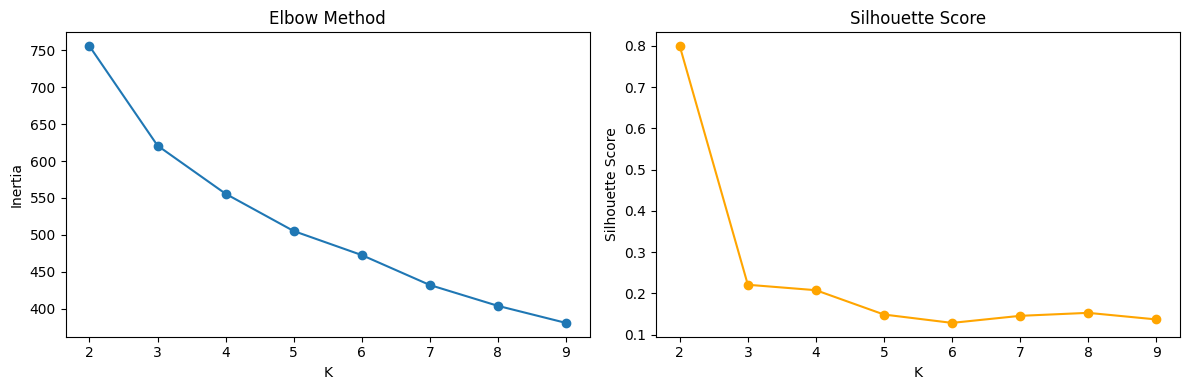

PCA explained variance: [0.36817081 0.55974801]


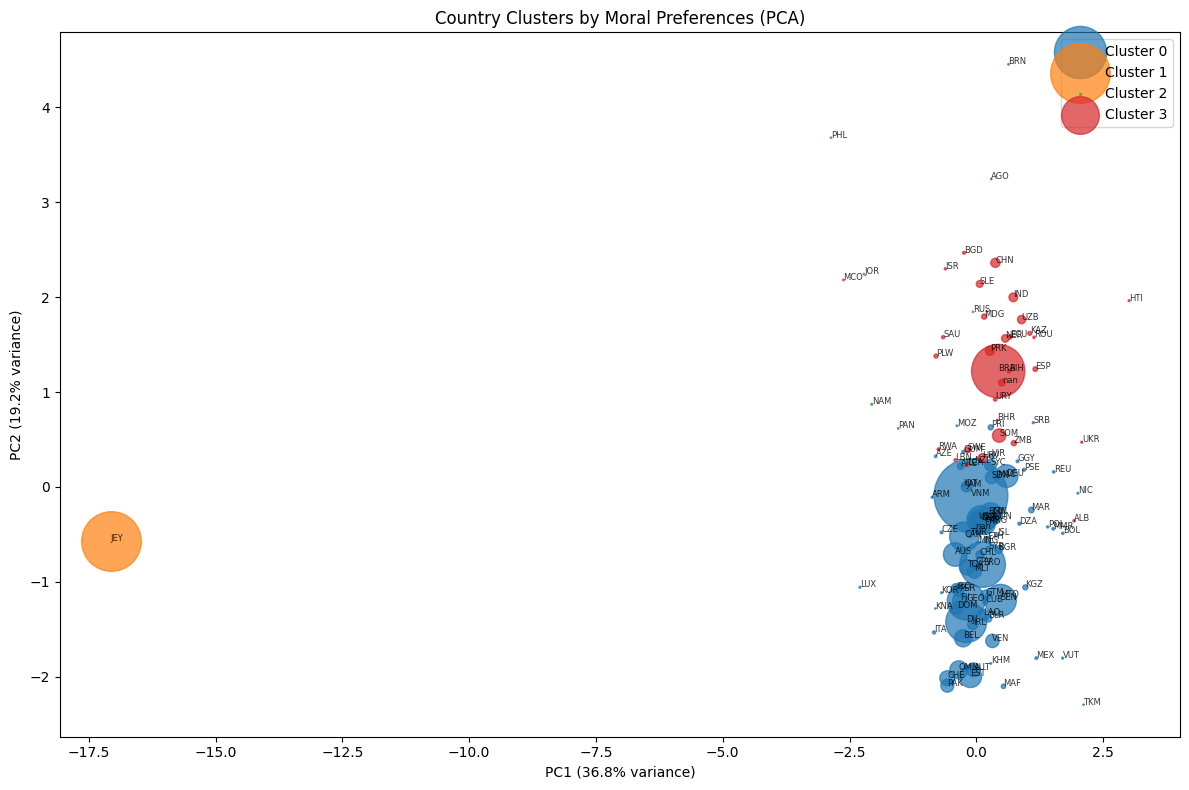


Cluster profiles:
         save_rate  avg_diff_humans  avg_diff_animals  avg_diff_young  avg_diff_old  avg_political  avg_religious  avg_income  avg_education
cluster                                                                                                                                     
0            0.504            0.005            -0.002           0.006         0.005          0.009         -0.010       2.318          2.617
1            0.501           -0.700             0.700          -0.301        -0.296          0.554          0.808       6.746          2.858
2            0.510           -0.095             0.081          -0.065         0.046         -0.107          0.370       1.412          1.774
3            0.503            0.001             0.007          -0.009         0.023         -0.191          0.659       1.742          2.336

Countries per cluster:

Cluster 0 (79 countries): ['ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BEL', 'BGR', 'BLR', 'BOL', 'CAN', 'CHE',

In [30]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Decode country names ──────────────────────────────────────────────────────
sample      = pd.read_csv("Datasets/SharedResponses_merged.csv", nrows=500000)
country_map = {i: v for i, v in enumerate(sorted(sample["UserCountry3"].dropna().unique()))}
country_agg["country"] = country_agg["UserCountry3_enc"].map(country_map)

# ── Step 2: Find optimal K using elbow + silhouette ──────────────────────────
features = ["save_rate", "avg_diff_humans", "avg_diff_animals",
            "avg_diff_young", "avg_diff_old", "avg_political",
            "avg_religious", "avg_income", "avg_education"]

X = country_agg[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, "o-")
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(K_range, silhouettes, "o-", color="orange")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score")
plt.tight_layout()
plt.savefig("kmeans_selection.png", dpi=150)
plt.show()

# ── Step 3: Fit KMeans with best K ───────────────────────────────────────────
# Pick K based on elbow/silhouette — starting with 4 as a reasonable guess
BEST_K = 4
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
country_agg["cluster"] = km.fit_predict(X_scaled)

# ── Step 4: PCA for visualisation ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
country_agg["pca1"] = X_pca[:, 0]
country_agg["pca2"] = X_pca[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.cumsum()}")

plt.figure(figsize=(12, 8))
for cluster in range(BEST_K):
    mask = country_agg["cluster"] == cluster
    plt.scatter(
        country_agg.loc[mask, "pca1"],
        country_agg.loc[mask, "pca2"],
        label=f"Cluster {cluster}",
        s=country_agg.loc[mask, "n_responses"] / 100,  # size = response count
        alpha=0.7
    )
    # Label each country
    for _, row in country_agg[mask].iterrows():
        plt.annotate(row["country"], (row["pca1"], row["pca2"]),
                    fontsize=6, alpha=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Country Clusters by Moral Preferences (PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150)
plt.show()

# ── Step 5: Cluster profiles ─────────────────────────────────────────────────
print("\nCluster profiles:")
print(country_agg.groupby("cluster")[features].mean().round(3).to_string())

print("\nCountries per cluster:")
for c in range(BEST_K):
    countries = country_agg[country_agg["cluster"] == c]["country"].tolist()
    print(f"\nCluster {c} ({len(countries)} countries): {countries}")

In [31]:
# ── Clean up nan country ──────────────────────────────────────────────────────
country_agg = country_agg.dropna(subset=["country"])
print(f"Countries after removing nan: {len(country_agg)}")

# ── Recheck silhouette scores ─────────────────────────────────────────────────
for k, s in zip(K_range, silhouettes):
    print(f"K={k}: silhouette={s:.4f}")

Countries after removing nan: 115
K=2: silhouette=0.7990
K=3: silhouette=0.2211
K=4: silhouette=0.2080
K=5: silhouette=0.1490
K=6: silhouette=0.1288
K=7: silhouette=0.1459
K=8: silhouette=0.1531
K=9: silhouette=0.1372


    n_responses  avg_income  avg_political
96       184532    6.745638       0.553728
Countries with 500+ responses: 74
K=2: silhouette=0.8226
K=3: silhouette=0.2546
K=4: silhouette=0.1777
K=5: silhouette=0.1849
K=6: silhouette=0.1782
K=7: silhouette=0.1803
K=8: silhouette=0.1720
K=9: silhouette=0.1670

Best K: 2


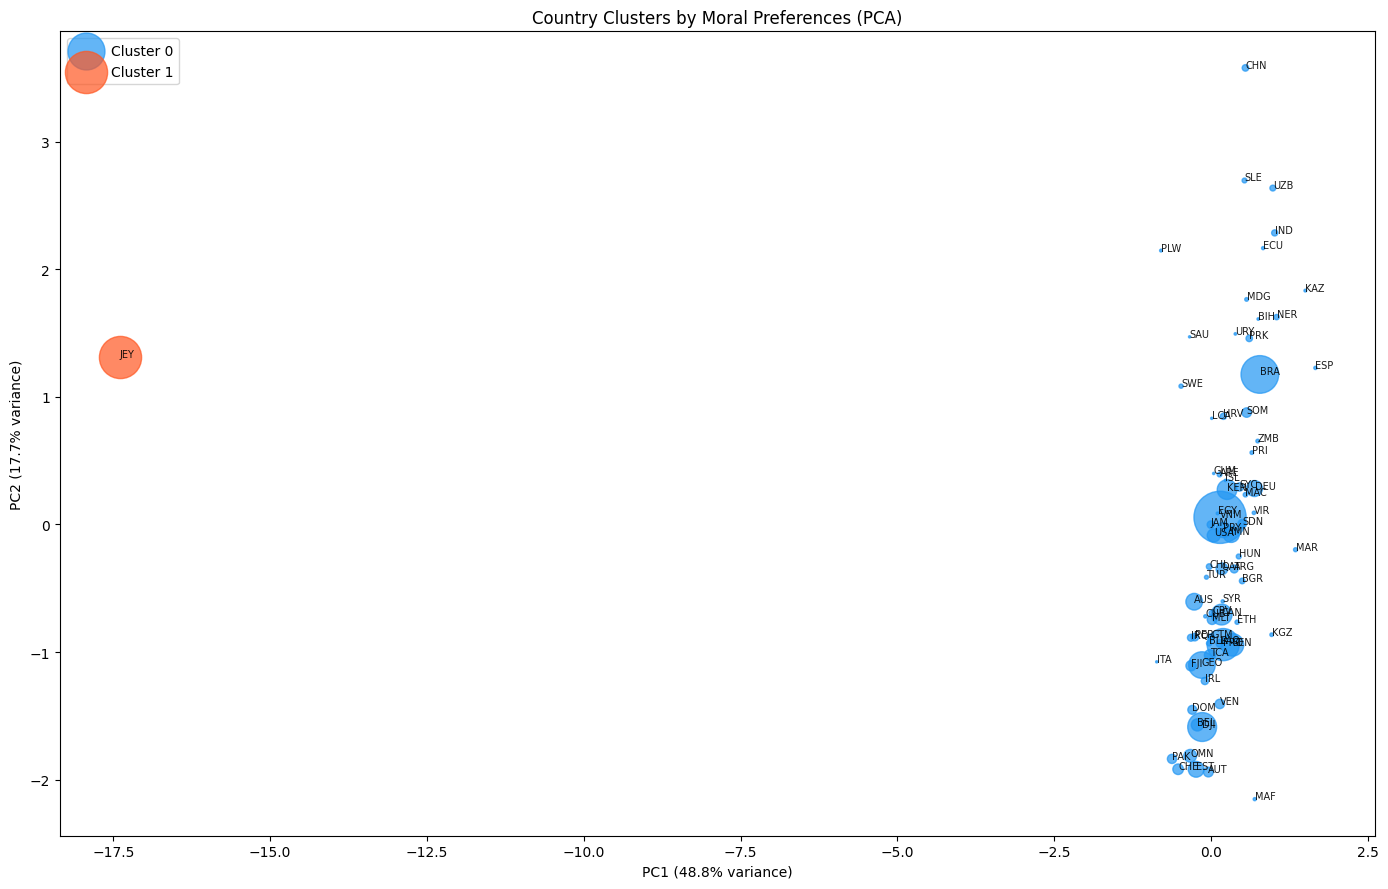


Cluster profiles:
         save_rate  avg_diff_humans  avg_diff_animals  avg_diff_young  avg_diff_old  avg_political  avg_religious  avg_income  avg_education
cluster                                                                                                                                     
0            0.503             -0.0             0.002          -0.003         0.014         -0.020          0.130       2.161          2.519
1            0.501             -0.7             0.700          -0.301        -0.296          0.554          0.808       6.746          2.858

Countries per cluster:

Cluster 0 (73 countries): ['ARE', 'ARG', 'AUS', 'AUT', 'BEL', 'BGR', 'BIH', 'BLR', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'CPV', 'CUB', 'DEU', 'DJI', 'DOM', 'ECU', 'EGY', 'ESP', 'EST', 'ETH', 'FJI', 'FRO', 'GEO', 'GTM', 'GUM', 'HRV', 'HUN', 'IMN', 'IND', 'IRL', 'IRQ', 'ISL', 'ITA', 'JAM', 'KAZ', 'KEN', 'KGZ', 'LAO', 'LCA', 'MAC', 'MAF', 'MAR', 'MDG', 'MLT', 'NER', 'OMN', 'PAK', 'PER', 'PLW', '

In [32]:
print(country_agg[country_agg["country"] == "JEY"][["n_responses", "avg_income", "avg_political"]])

# Rerun with K=3 excluding outliers
country_agg_clean = country_agg[country_agg["n_responses"] >= 500].copy()
print(f"Countries with 500+ responses: {len(country_agg_clean)}")

X_clean = scaler.fit_transform(country_agg_clean[features].values)

silhouettes_clean = []
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clean)
    silhouettes_clean.append(silhouette_score(X_clean, labels))
    print(f"K={k}: silhouette={silhouette_score(X_clean, labels):.4f}")

# Pick best K
BEST_K = K_range[np.argmax(silhouettes_clean)]
print(f"\nBest K: {BEST_K}")

# Refit with best K
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
country_agg_clean["cluster"] = km_final.fit_predict(X_clean)

# PCA
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_clean)
country_agg_clean["pca1"] = X_pca[:, 0]
country_agg_clean["pca2"] = X_pca[:, 1]

# Plot
plt.figure(figsize=(14, 9))
colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]
for cluster in range(BEST_K):
    mask = country_agg_clean["cluster"] == cluster
    plt.scatter(
        country_agg_clean.loc[mask, "pca1"],
        country_agg_clean.loc[mask, "pca2"],
        label=f"Cluster {cluster}",
        color=colors[cluster],
        s=country_agg_clean.loc[mask, "n_responses"] / 200,
        alpha=0.7
    )
    for _, row in country_agg_clean[mask].iterrows():
        plt.annotate(row["country"], (row["pca1"], row["pca2"]),
                    fontsize=7, alpha=0.9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Country Clusters by Moral Preferences (PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("pca_clusters_clean.png", dpi=150)
plt.show()

# Cluster profiles
print("\nCluster profiles:")
print(country_agg_clean.groupby("cluster")[features].mean().round(3).to_string())
print("\nCountries per cluster:")
for c in range(BEST_K):
    countries = country_agg_clean[country_agg_clean["cluster"] == c]["country"].tolist()
    print(f"\nCluster {c} ({len(countries)} countries): {countries}")

Responses for JEY: check
    n_responses  avg_income  avg_political  avg_religious
96       184532    6.745638       0.553728       0.807944
K=2: silhouette=0.2191
K=3: silhouette=0.1128
K=4: silhouette=0.1368
K=5: silhouette=0.1347
K=6: silhouette=0.1438
K=7: silhouette=0.1062
K=8: silhouette=0.1433
K=9: silhouette=0.1218

Best K: 2


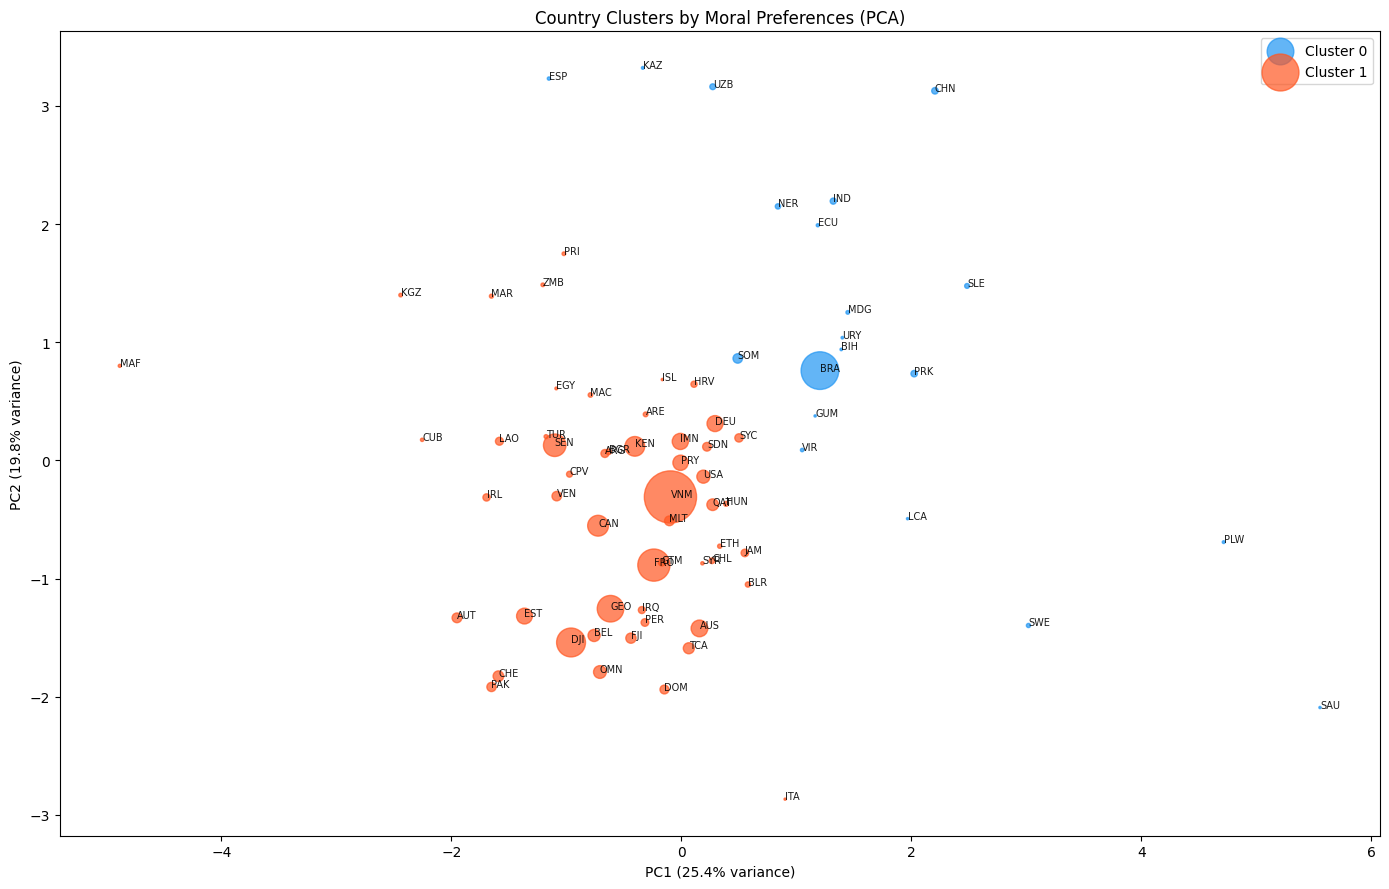


Cluster profiles:
         save_rate  avg_diff_humans  avg_diff_animals  avg_diff_young  avg_diff_old  avg_political  avg_religious  avg_income  avg_education
cluster                                                                                                                                     
0            0.503           -0.006             0.014          -0.005         0.019         -0.171          0.650       1.619          2.372
1            0.503            0.002            -0.003          -0.002         0.012          0.037         -0.066       2.365          2.575

Countries per cluster:

Cluster 0 (20 countries): ['BIH', 'BRA', 'CHN', 'ECU', 'ESP', 'GUM', 'IND', 'KAZ', 'LCA', 'MDG', 'NER', 'PLW', 'PRK', 'SAU', 'SLE', 'SOM', 'SWE', 'URY', 'UZB', 'VIR']

Cluster 1 (53 countries): ['ARE', 'ARG', 'AUS', 'AUT', 'BEL', 'BGR', 'BLR', 'CAN', 'CHE', 'CHL', 'CPV', 'CUB', 'DEU', 'DJI', 'DOM', 'EGY', 'EST', 'ETH', 'FJI', 'FRO', 'GEO', 'GTM', 'HRV', 'HUN', 'IMN', 'IRL', 'IRQ', 'ISL', '

In [33]:
# ── Remove JEY outlier and rerun ─────────────────────────────────────────────
country_agg_clean = country_agg_clean[country_agg_clean["country"] != "JEY"].copy()
print(f"Responses for JEY: check")
print(country_agg[country_agg["country"] == "JEY"][["n_responses", "avg_income", "avg_political", "avg_religious"]])

# Refit scaler and cluster without JEY
X_clean = scaler.fit_transform(country_agg_clean[features].values)

silhouettes_clean = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clean)
    s = silhouette_score(X_clean, labels)
    silhouettes_clean.append(s)
    print(f"K={k}: silhouette={s:.4f}")

BEST_K = K_range[np.argmax(silhouettes_clean)]
print(f"\nBest K: {BEST_K}")

# Refit with best K
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
country_agg_clean["cluster"] = km_final.fit_predict(X_clean)

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clean)
country_agg_clean["pca1"] = X_pca[:, 0]
country_agg_clean["pca2"] = X_pca[:, 1]

# Plot
plt.figure(figsize=(14, 9))
colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]
for cluster in range(BEST_K):
    mask = country_agg_clean["cluster"] == cluster
    plt.scatter(
        country_agg_clean.loc[mask, "pca1"],
        country_agg_clean.loc[mask, "pca2"],
        label=f"Cluster {cluster}",
        color=colors[cluster],
        s=country_agg_clean.loc[mask, "n_responses"] / 200,
        alpha=0.7
    )
    for _, row in country_agg_clean[mask].iterrows():
        plt.annotate(row["country"], (row["pca1"], row["pca2"]),
                    fontsize=7, alpha=0.9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Country Clusters by Moral Preferences (PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("pca_clusters_clean.png", dpi=150)
plt.show()

print("\nCluster profiles:")
print(country_agg_clean.groupby("cluster")[features].mean().round(3).to_string())
print("\nCountries per cluster:")
for c in range(BEST_K):
    countries = country_agg_clean[country_agg_clean["cluster"] == c]["country"].tolist()
    print(f"\nCluster {c} ({len(countries)} countries): {countries}")

K=2: silhouette=0.1498
K=3: silhouette=0.1350
K=4: silhouette=0.1434
K=5: silhouette=0.1303
K=6: silhouette=0.1407
K=7: silhouette=0.1384
K=8: silhouette=0.1403
K=9: silhouette=0.1474

Best K: 2


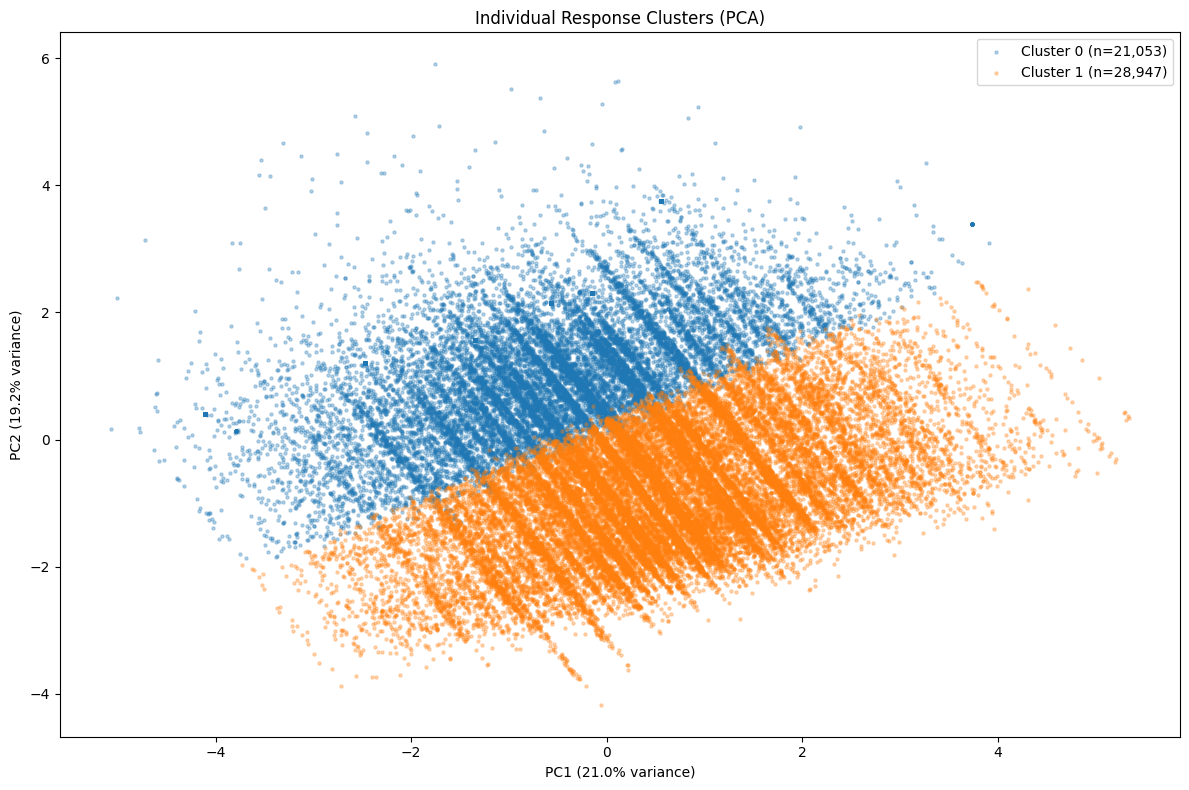


Running t-SNE...


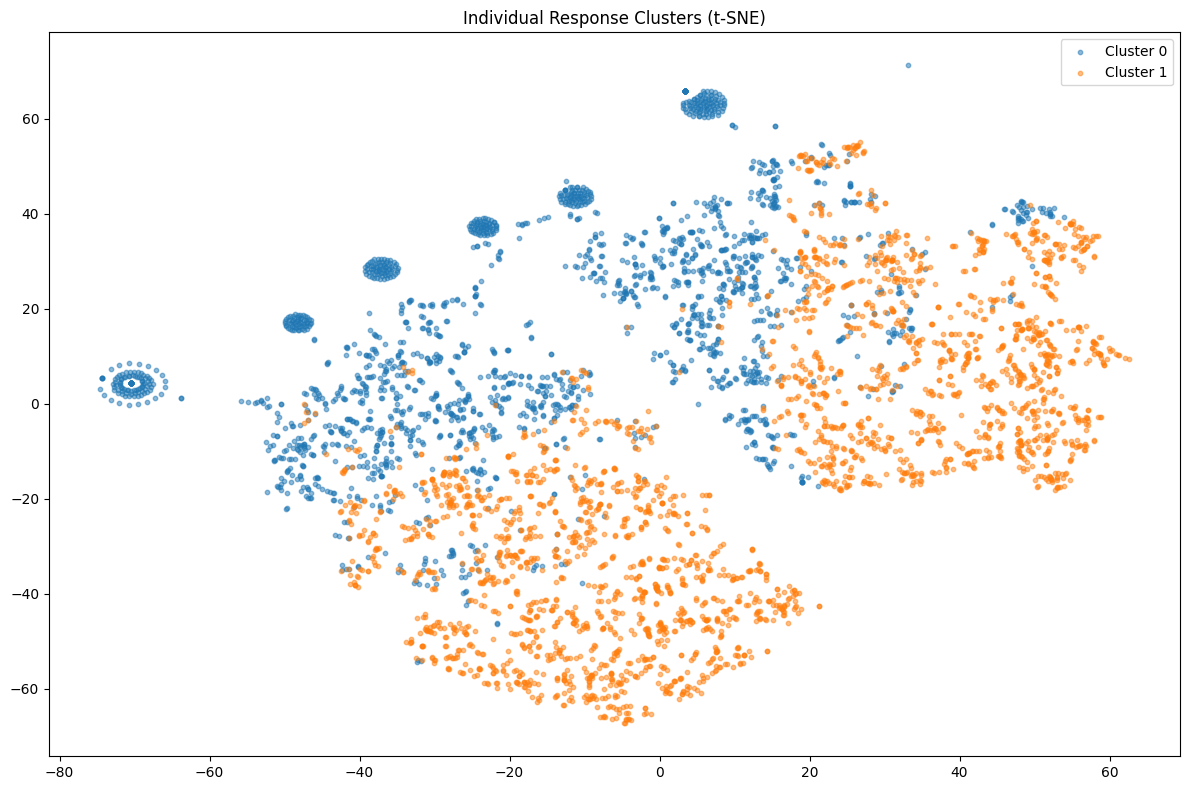


Cluster profiles:
         diff_humans  diff_animals  diff_young  diff_old  diff_total_characters  DefaultChoiceIsOmission_swerve  Review_political_scaled  Review_religious_scaled  Review_income_enc  Review_education_enc  Review_age_scaled  Saved
cluster                                                                                                                                                                                                                             
0             -0.352         0.249      -0.144    -0.124                 -0.104                           0.493                    0.237                    0.257              6.347                 3.772              1.130  0.509
1              0.109        -0.034       0.031     0.047                  0.075                           0.496                   -0.058                    0.004              0.571                 1.432             -0.482  0.498


In [35]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_parquet("SharedResponses_final.parquet")
y  = df["Saved"].astype(int)

# ── Use the most meaningful features for clustering ───────────────────────────
cluster_features = [
    "diff_humans", "diff_animals", "diff_young", "diff_old",
    "diff_total_characters", "DefaultChoiceIsOmission_swerve",
    "Review_political_scaled", "Review_religious_scaled",
    "Review_income_enc", "Review_education_enc", "Review_age_scaled"
]

# Sample 50k rows for clustering — full 1.45M is too slow for KMeans tuning
sample = df[cluster_features].sample(50000, random_state=42)
y_sample = y[sample.index]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(sample)

# ── Find optimal K ────────────────────────────────────────────────────────────
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    s      = silhouette_score(X_scaled, labels, sample_size=10000)
    silhouettes.append(s)
    print(f"K={k}: silhouette={s:.4f}")

BEST_K = K_range[np.argmax(silhouettes)]
print(f"\nBest K: {BEST_K}")

# ── Fit final KMeans ──────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
sample["cluster"] = km_final.fit_predict(X_scaled)
sample["Saved"]   = y_sample.values

# ── PCA visualisation ─────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
# Use a colormap to handle any number of clusters without IndexError
cmap = plt.get_cmap("tab10") 
for c in range(BEST_K):
    mask = sample["cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {c} (n={mask.sum():,})",
                color=cmap(c), alpha=0.3, s=5)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Individual Response Clusters (PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("pca_individual_clusters.png", dpi=150)
plt.show()

# ── t-SNE visualisation (on 5k subset — t-SNE is slow) ───────────────────────
print("\nRunning t-SNE...")
tsne    = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
subset  = X_scaled[:5000]
X_tsne  = tsne.fit_transform(subset)
labels_subset = sample["cluster"].values[:5000]

plt.figure(figsize=(12, 8))
for c in range(BEST_K):
    mask = labels_subset == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=f"Cluster {c}",
                color=cmap(c), alpha=0.5, s=10)

plt.title("Individual Response Clusters (t-SNE)")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_clusters.png", dpi=150)
plt.show()

# ── Cluster profiles ──────────────────────────────────────────────────────────
print("\nCluster profiles:")
print(sample.groupby("cluster")[cluster_features + ["Saved"]].mean().round(3).to_string())

In [36]:
# ── Save cluster assignments ──────────────────────────────────────────────────
print("Cluster sizes:")
print(sample["cluster"].value_counts())

print("\nSave rate per cluster:")
print(sample.groupby("cluster")["Saved"].mean().round(3))

print("\nKey insight:")
print("Low silhouette scores (0.13-0.15) indicate moral preferences")
print("exist on a continuum — no sharply distinct moral groups found.")
print("K=2 reveals a weak but interpretable split between:")
print("  Cluster 0: older, wealthier, more religious — animal preference")
print("  Cluster 1: younger, lower income, neutral — human preference")

# ── Save for reporting ────────────────────────────────────────────────────────
sample.to_parquet("SharedResponses_clustered.parquet", index=False)
print("\nSaved to SharedResponses_clustered.parquet")

Cluster sizes:
cluster
1    28947
0    21053
Name: count, dtype: int64

Save rate per cluster:
cluster
0    0.509
1    0.498
Name: Saved, dtype: float64

Key insight:
Low silhouette scores (0.13-0.15) indicate moral preferences
exist on a continuum — no sharply distinct moral groups found.
K=2 reveals a weak but interpretable split between:
  Cluster 0: older, wealthier, more religious — animal preference
  Cluster 1: younger, lower income, neutral — human preference

Saved to SharedResponses_clustered.parquet


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

# ── PCA on full dataset ───────────────────────────────────────────────────────
print("Running PCA on full dataset...")
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 9))
colors = ["#2196F3", "#FF5722"]
for c in [0, 1]:
    mask = df["cluster"] == c
    label = ("Cluster 0 — older, wealthy, religious, animal preference" if c == 0
             else "Cluster 1 — younger, lower income, human preference")
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, color=colors[c], alpha=0.1, s=1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Moral Preference Clusters — PCA (1.45M responses)")
plt.legend(markerscale=10)
plt.tight_layout()
plt.savefig("pca_full.png", dpi=150)
plt.show()
print(f"PCA done. Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# ── t-SNE on full dataset ─────────────────────────────────────────────────────
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Running UMAP on full dataset...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1, verbose=True)
X_umap  = reducer.fit_transform(X_scaled)

colors = ["#2196F3", "#FF5722"]
plt.figure(figsize=(14, 9))
for c in [0, 1]:
    mask = df["cluster"].values == c
    label = ("Cluster 0 — older, wealthy, religious" if c == 0
             else "Cluster 1 — younger, lower income")
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                label=label, color=colors[c], alpha=0.1, s=1)

plt.title("Moral Preference Clusters — UMAP (1.45M responses)")
plt.legend(markerscale=10)
plt.tight_layout()
plt.savefig("umap_full.png", dpi=150)
plt.show()
print("UMAP done.")

Running PCA on full dataset...


KeyError: 'cluster'

<Figure size 1400x900 with 0 Axes>